# Dataframer: Richmond Latimore's Odyssey to Pandas DF

### [—————————————pipeline—————————————]
### »——raw—»—clean—»—normalize—»—DATAFRAME——»

Here are some transformation and frequencies for future exploratory analysis of Green's Odyssey.

Columns: author, year, title, book_num, text, num_lines, num_sentences, num_words, 


In [1]:
import os
import numpy as np
import pandas as pd

import re
import nltk

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('/Users/debr/English-Homer') 
import bard_visualization as viz# This will apply the visualization settings
from bard_visualization import color_palette 
sys.path.append('/Users/debr/English-Homer/functions') 
import e_nlp as e

In [3]:
# TO UPDATE
translator = "Lattimore" 

# Check Paths
filepath = f"/Users/debr/odysseys_en/Normalized_txts/Odyssey_{translator}_Normalized_v2.txt"
output_path = f"/Users/debr/English-Homer/dataframers_by_author/{translator}_DFed/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
output_path_plots = f"{output_path}/plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)

# READING FILE TO extracted_lines
with open(filepath, 'r') as file:
    extracted_lines = file.readlines()

text = "".join(extracted_lines)

In [4]:
book_breaker = "BOOK"

#books = string_into_books(text, book_breaker)
books = e.list_into_books(extracted_lines, book_breaker)

# Verify the results
print(f"Found {len(books)} books")
for i, book in enumerate(books):
    print(f"Book {i+1} starts with: {book[0]}")
    print(f"Book {i+1} has {len(book)} lines")

Found 24 books
Book 1 starts with: Tell me, Muse, of the man of many ways, who was driven

Book 1 has 455 lines
Book 2 starts with: Now when the young Dawn showed again with her rosy fingers, the dear

Book 2 has 442 lines
Book 3 starts with: Helios, leaving behind the lovely standing waters, rose up

Book 3 has 510 lines
Book 4 starts with: They came into the cavernous hollow of Lakedaimon

Book 4 has 871 lines
Book 5 starts with: Now Dawn rose from her bed, where she lay by haughty Tithonos,

Book 5 has 507 lines
Book 6 starts with: So long-suffering great Odysseus slept in that place

Book 6 has 334 lines
Book 7 starts with: So long-suffering great Odysseus prayed, in that place,

Book 7 has 353 lines
Book 8 starts with: Then when the young Dawn showed again with her rosy fingers,

Book 8 has 600 lines
Book 9 starts with: Then resourceful Odysseus spoke in turn and answered him: ‘O great

Book 9 has 568 lines
Book 10 starts with: ‘We came next to the Aiolian island, whereAiolos

Boo

In [5]:
df = e.book_into_df(f"{translator}", "1965", "The Odyssey", books)

In [6]:
df['num_lines'] = df['text'].apply(e.count_lines)
df['num_sentences'] = df['text'].apply(e.count_sentences)
df['num_words'] = df['text'].apply(e.count_words)

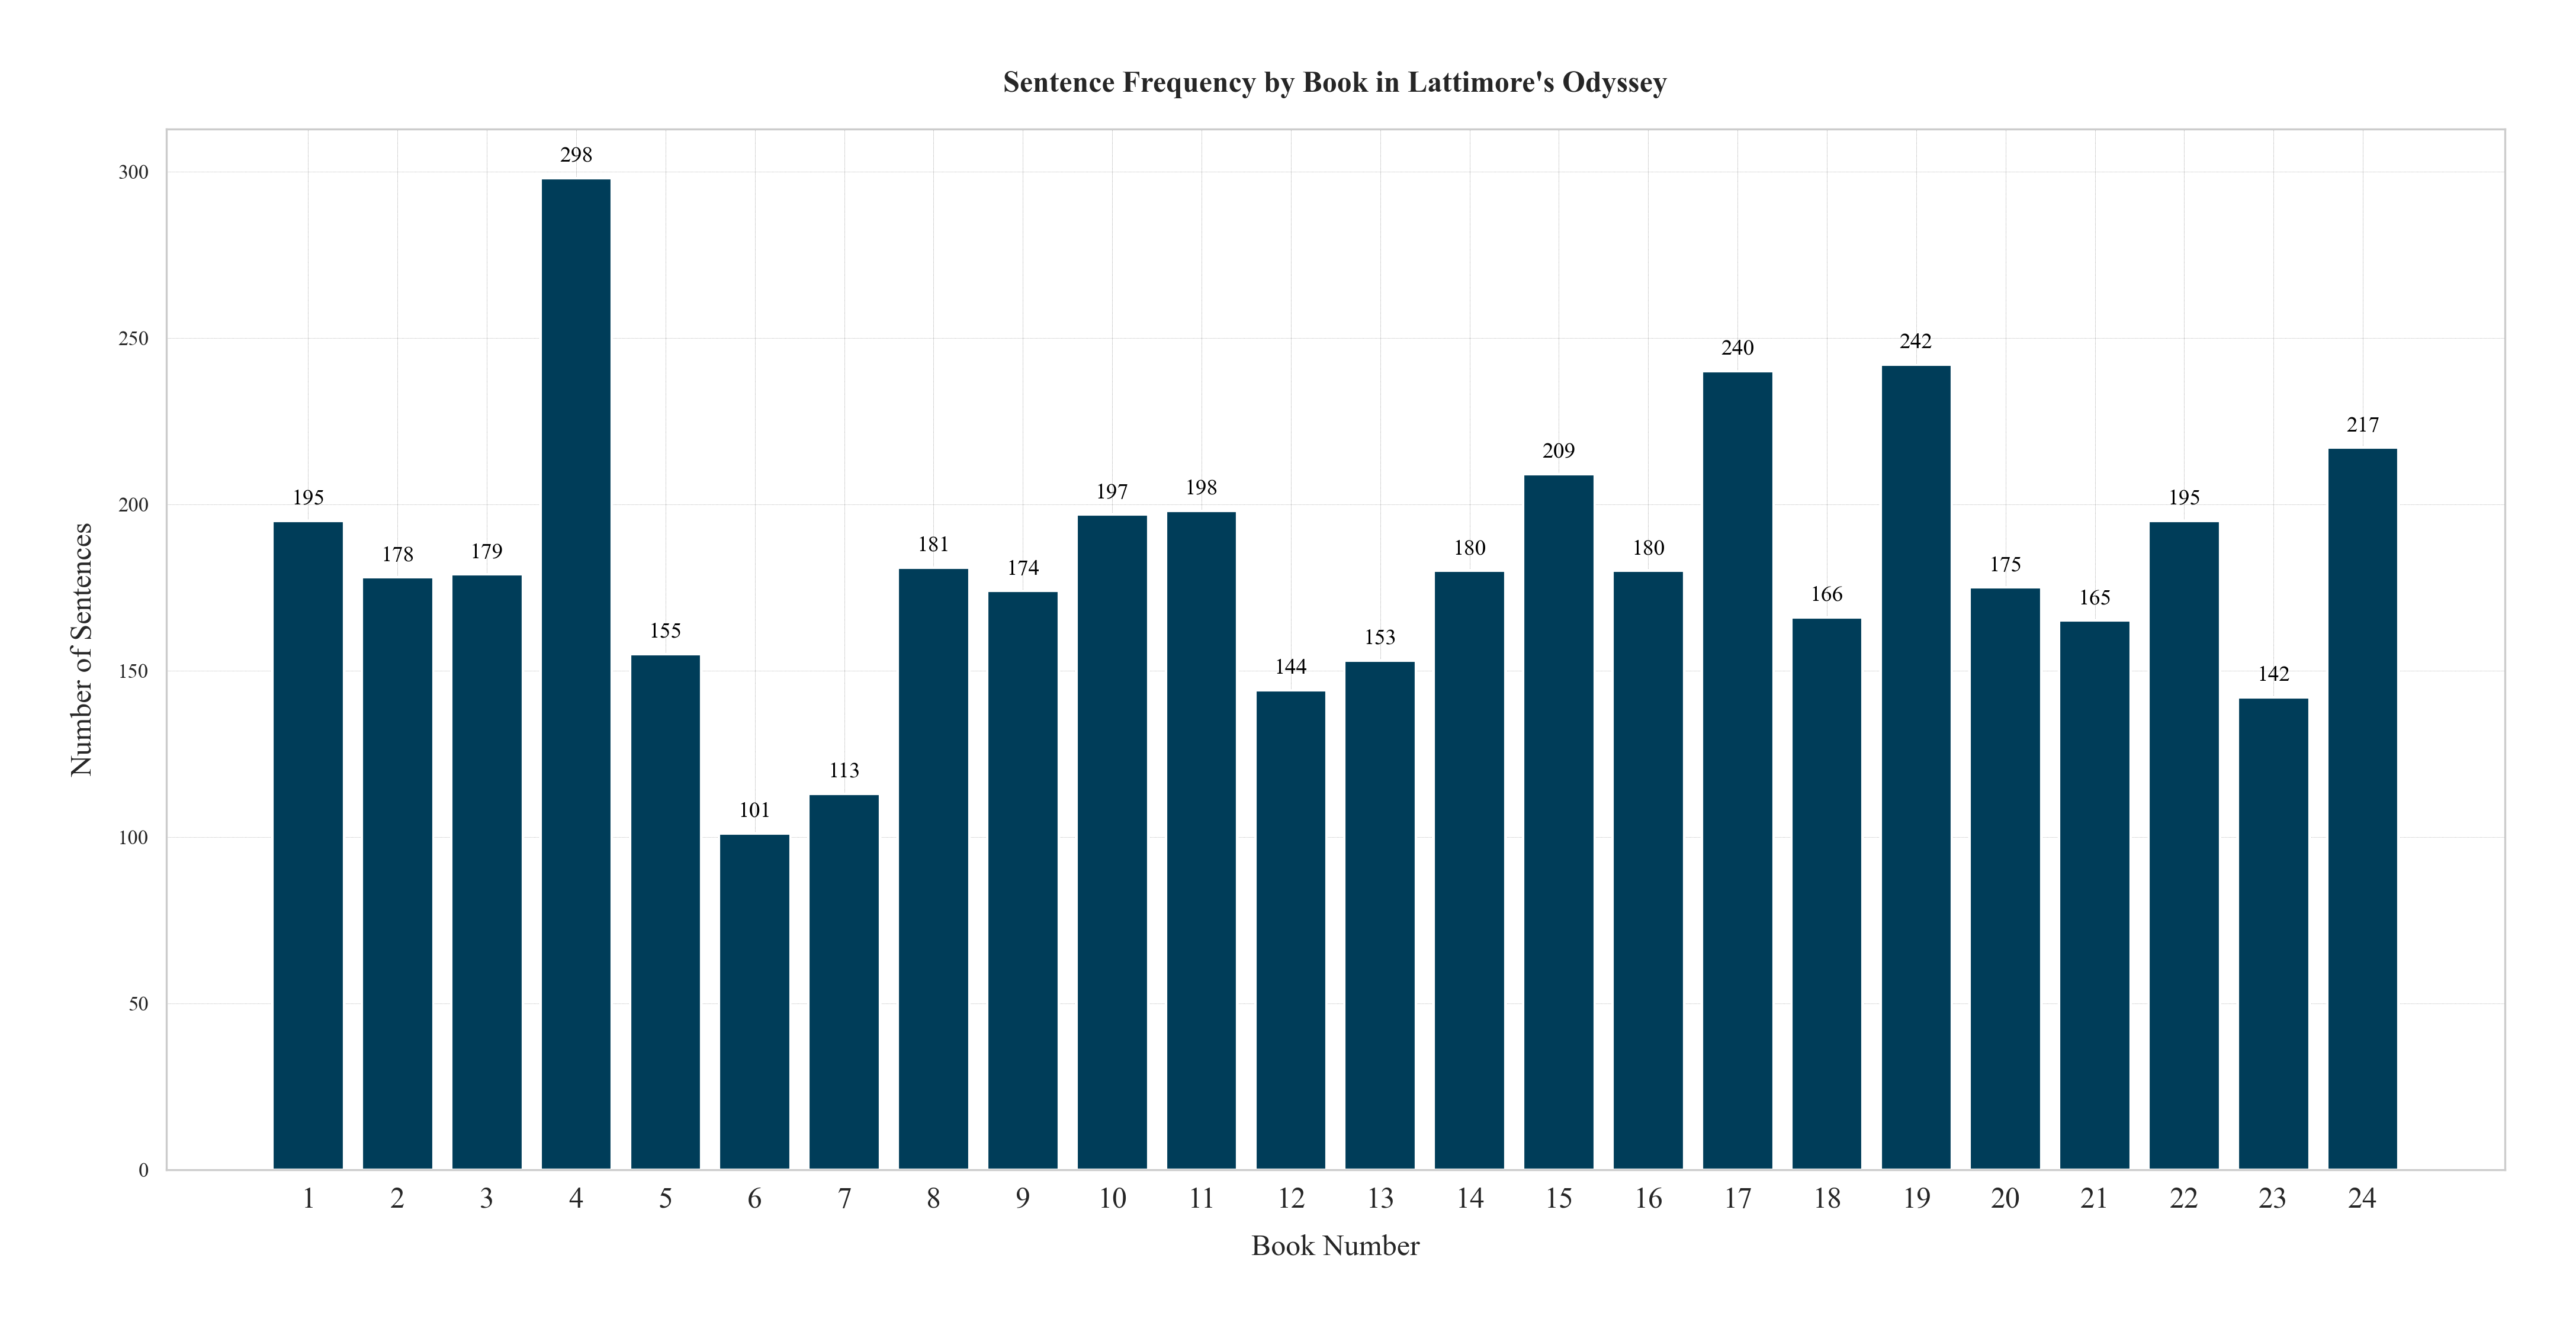

In [8]:
# Group by book_num and count the number of sentences in each book
sentences_per_book = df.groupby('book_num')['num_sentences'].sum()

# Create the plot using predefined styles
fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(sentences_per_book.index, sentences_per_book.values, color=color_palette["astroblue"])  

ax.set_xlabel('Book Number')
ax.set_ylabel('Number of Sentences')
ax.set_title(f"Sentence Frequency by Book in {translator}'s Odyssey")
ax.grid(axis='y', alpha=0.4)
ax.set_xticks(sentences_per_book.index)   # Ensure all book numbers are shown on the x-axis
for i, v in enumerate(sentences_per_book.values): # Add values on top of bars
    ax.text(i + 1, v + 5, str(v), ha='center', fontsize=9, color='black')
plt.tight_layout()
plt.savefig(f"{output_path_plots}/{translator}-sentence_freq.png")

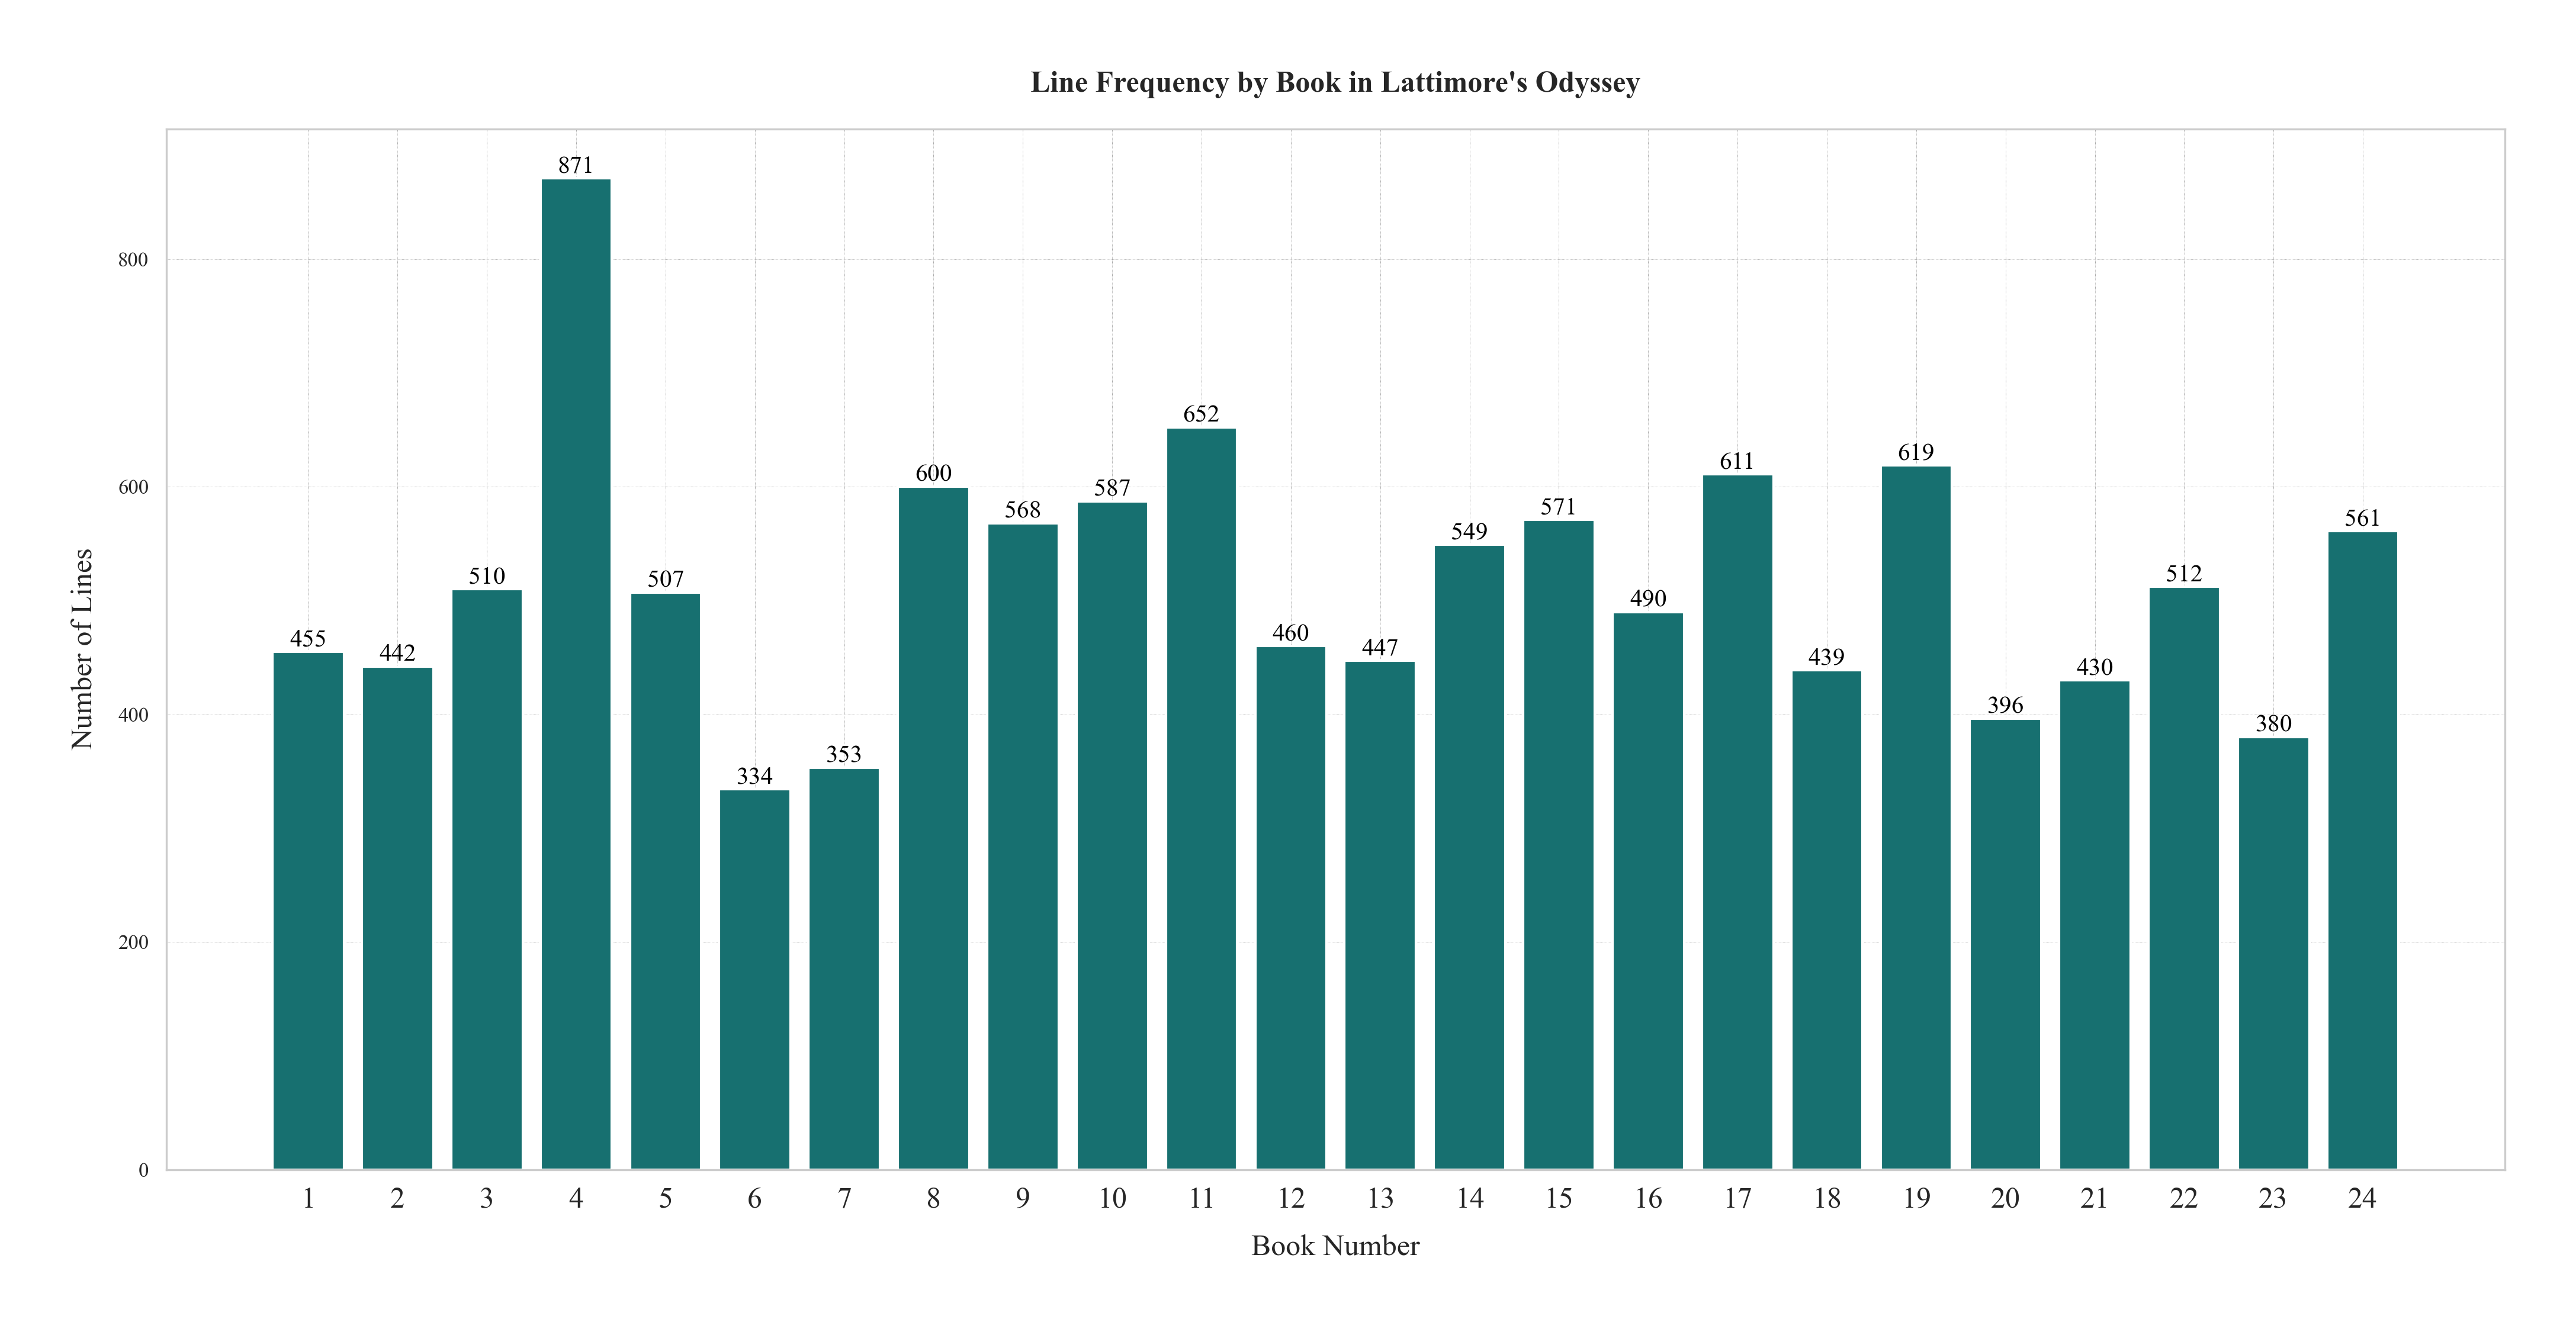

In [ ]:
# Group by book_num and count the number of lines in each book
lines_per_book = df.groupby('book_num')['num_lines'].sum()

# Create the plot using predefined styles
fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(lines_per_book.index, lines_per_book.values, color=color_palette["genoa"])  
ax.set_xlabel('Book Number')
ax.set_ylabel('Number of Lines')
ax.set_title(f"Line Frequency by Book in {translator}'s Odyssey")
ax.grid(axis='y', alpha=0.4)
# Ensure all book numbers are shown on the x-axis
ax.set_xticks(lines_per_book.index)

# Add values on top of bars
for i, v in enumerate(lines_per_book.values):
    ax.text(i + 1, v + 5, str(v), ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.savefig(f"{output_path_plots}/{translator}-lines_freq.png")

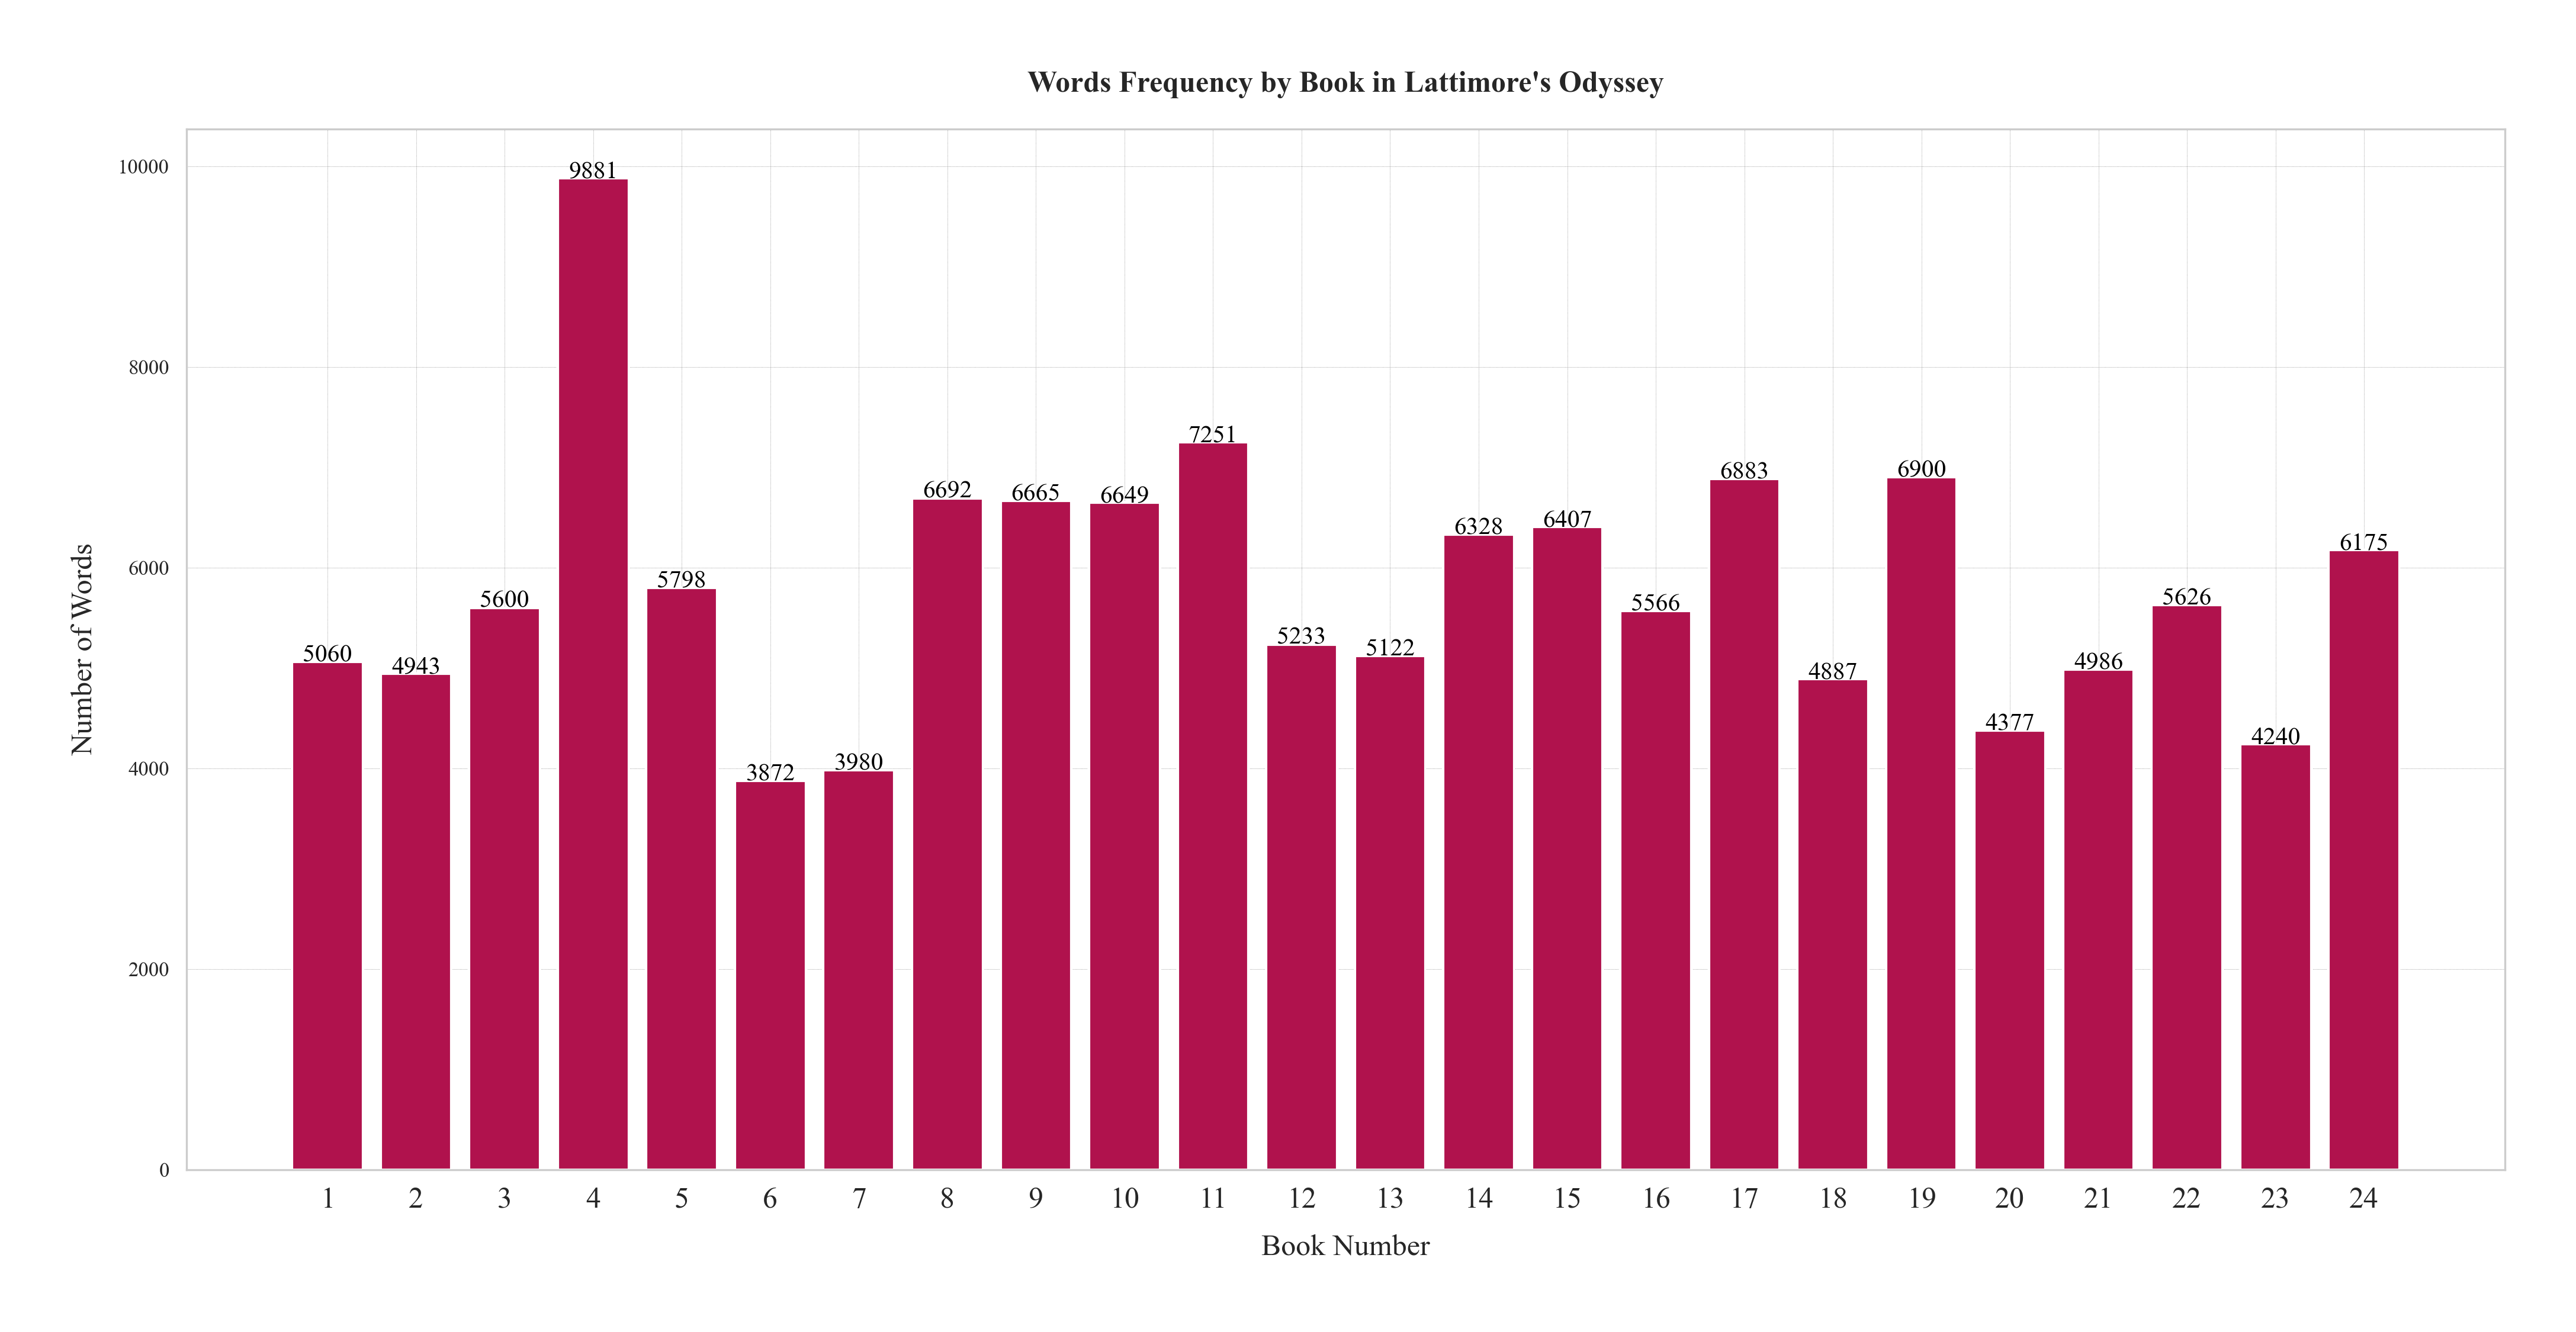

In [ ]:
# Group by book_num and count the number of words in each book
words_per_book = df.groupby('book_num')['num_words'].sum()
# Create the plot using predefined styles
fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(words_per_book.index, words_per_book.values, color=color_palette["jazzberry"])
ax.set_xlabel('Book Number')
ax.set_ylabel('Number of Words')
ax.set_title(f"Words Frequency by Book in {translator}'s Odyssey")
ax.grid(axis='y', alpha=0.5)

# Ensure all book numbers are shown on the x-axis
ax.set_xticks(words_per_book.index)

# Add values on top of bars
for i, v in enumerate(words_per_book.values):
    ax.text(i + 1, v + 5, str(v), ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.savefig(f"{output_path_plots}/{translator}-words_freq_bB.png")

In [15]:
df['text'][0][:3]

['Tell me, Muse, of the man of many ways, who was driven\n',
 "far journeys, after he had sacked Troy's sacred citadel.\n",
 'Many were they whose cities he saw, whose minds he learned of,\n']

In [ ]:
df['text'] = df['text'].apply(e.remove_newline_character)

In [18]:
df['text'][0][:3]

['Tell me, Muse, of the man of many ways, who was driven',
 "far journeys, after he had sacked Troy's sacred citadel.",
 'Many were they whose cities he saw, whose minds he learned of,']

In [24]:
#Boolean check for missing values

e.check_df(df)

AttributeError: module 'e_nlp' has no attribute 'check_df'

In [ ]:
# Create directory OUTSIDE the project folder
output_filepath = f"/Users/debr/odysseys_en/Odyssey_dfs/Odyssey_{translator}_eda.csv"
os.makedirs(os.path.dirname(output_filepath), exist_ok=True)

# save df to csv
df.to_csv(output_filepath, index=False)

print(f"Normalization complete. File saved to: {output_filepath}")